# Real-time Seizure Monitoring — Machine Learning Project

Predicting whether a *seizure* is occurring or not using EEG (brain electrical activity) signals.

*Dataset:* UCI Machine Learning Repository — Epileptic Seizure Recognition (originally from Andrzejak et al., University of Bonn EEG database)

*Dataset Structure:* 11,500 rows; each row represents a 1-second EEG signal containing 178 sample points (X1 through X178)

*Class Transformation:* The original target label (y) consisted of 5 classes (1 = Seizure, 2–5 = various non-seizure states). Convert this into a binary classification problem:

1: *Seizure*

0: *Non-Seizure*


In [1]:
!pip install -q requests beautifulsoup4 pandas numpy scikit-learn matplotlib seaborn joblib

## Step 1: Data Fetching

We use requests and BeautifulSoup to first scrape the UCI dataset page (to extract its title and description), and then download the actual CSV data. If the UCI server is unreachable, the pipeline automatically fetches the data from a GitHub mirror.

In [2]:
import os
import requests
from bs4 import BeautifulSoup

UCI_PAGE_URL = "https://archive.ics.uci.edu/dataset/388/epileptic+seizure+recognition"
UCI_DIRECT_CSV = "https://archive.ics.uci.edu/ml/machine-learning-databases/00388/data.csv"
GITHUB_MIRROR_CSV = (
    "https://raw.githubusercontent.com/Jreevo/"
    "Epileptic-Seizure-Binary-Classification/master/epilepsy.csv"
)

DATA_DIR = "data"
RAW_CSV_PATH = os.path.join(DATA_DIR, "epileptic_seizure_data.csv")
HEADERS = {"User-Agent": "Mozilla/5.0 (research project data fetch script)"}


def scrape_dataset_page(url: str = UCI_PAGE_URL) -> dict:
    info = {"title": None, "description": None, "source_url": url}
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        resp.raise_for_status()
        soup = BeautifulSoup(resp.text, "html.parser")

        title_tag = soup.find("h1")
        if title_tag:
            info["title"] = title_tag.get_text(strip=True)

        for p in soup.find_all("p"):
            text = p.get_text(strip=True)
            if len(text) > 80:
                info["description"] = text
                break

        print("[scrape] Page title      :", info["title"])
        print("[scrape] Page description:", (info["description"] or "")[:200], "...")
    except requests.exceptions.RequestException as exc:
        print(f"[scrape] Could not reach {url} ({exc}). Skipping metadata scrape.")
    return info


def download_csv(save_path: str = RAW_CSV_PATH) -> str:
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    for label, url in [("UCI direct", UCI_DIRECT_CSV), ("GitHub mirror", GITHUB_MIRROR_CSV)]:
        try:
            print(f"[download] Trying {label}: {url}")
            resp = requests.get(url, headers=HEADERS, timeout=30)
            resp.raise_for_status()
            with open(save_path, "wb") as f:
                f.write(resp.content)
            print(f"[download] Success via {label}. Saved to {save_path}")
            return save_path
        except requests.exceptions.RequestException as exc:
            print(f"[download] {label} failed ({exc}). Trying next source...")

    raise RuntimeError("Could not download the dataset from any known source.")


scrape_dataset_page()
csv_path = download_csv()
print("\nDataset ready at:", csv_path)

[scrape] Could not reach https://archive.ics.uci.edu/dataset/388/epileptic+seizure+recognition (403 Client Error: Forbidden for url: https://archive.ics.uci.edu/dataset/388/epileptic+seizure+recognition). Skipping metadata scrape.
[download] Trying UCI direct: https://archive.ics.uci.edu/ml/machine-learning-databases/00388/data.csv
[download] UCI direct failed (404 Client Error: Not Found for url: https://archive.ics.uci.edu/ml/machine-learning-databases/00388/data.csv). Trying next source...
[download] Trying GitHub mirror: https://raw.githubusercontent.com/Jreevo/Epileptic-Seizure-Binary-Classification/master/epilepsy.csv
[download] Success via GitHub mirror. Saved to data\epileptic_seizure_data.csv

Dataset ready at: data\epileptic_seizure_data.csv


## Step 2: Data Exploration

We load the dataset to inspect its structure, check data types, missing values, and analyze summary statistics.

In [3]:
import pandas as pd

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
df.head()

Shape: (11500, 180)


,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [4]:
print("Original 5-class label distribution:")
print(df["y"].value_counts())
# 1 = Seizure, 2-5 = various non-seizure brain states

Original 5-class label distribution:
y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64


## Step 3: Preprocessing

- Drop the Unnamed index column.

- Convert the target variable to binary: 1 = Seizure, 0 = Non-Seizure.

- Split the dataset into training and testing sets (80/20 ratio using stratified sampling).

- Scale features using StandardScaler.

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Unnamed column hatao
unnamed_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
df = df.drop(columns=unnamed_cols, errors="ignore")

# Binary target: 1 = Seizure, 0 = Non-Seizure
df["y"] = df["y"].apply(lambda v: 1 if v == 1 else 0)

print("Class balance after binarizing (1 = seizure, 0 = non-seizure):")
print(df["y"].value_counts(normalize=True).round(3))

Class balance after binarizing (1 = seizure, 0 = non-seizure):
y
0    0.8
1    0.2
Name: proportion, dtype: float64


In [6]:
X = df.drop(columns=["y"]).values
y = df["y"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)

Train shape: (9200, 178)  Test shape: (2300, 178)


## Step 4: Model Training

Train and compare three different classification models:

- Logistic Regression: Establishes a fast, linear baseline model.

- Random Forest Classifier: Captures complex, non-linear relationships using an ensemble of decision trees.

- Support Vector Machine (SVM): Utilizes a Radial Basis Function (RBF) kernel to project features into higher-dimensional space for optimal decision boundary separation.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "SVM_RBF": SVC(kernel="rbf", probability=True, random_state=42),
}

results = []
fitted = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    results.append(metrics)
    fitted[name] = (model, y_pred, y_proba)
    print(f"{name} -> " + ", ".join(f"{k}: {v:.4f}" for k, v in metrics.items() if k != "model"))


Training LogisticRegression...
LogisticRegression -> accuracy: 0.8157, precision: 0.9500, recall: 0.0826, f1: 0.1520, roc_auc: 0.4996

Training RandomForest...
RandomForest -> accuracy: 0.9778, precision: 0.9534, recall: 0.9348, f1: 0.9440, roc_auc: 0.9966

Training SVM_RBF...


c:\Users\MJ\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM_RBF -> accuracy: 0.9709, precision: 0.9538, recall: 0.8978, f1: 0.9250, roc_auc: 0.9965


In [8]:
results_df = pd.DataFrame(results).set_index("model")
results_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.815652,0.950000,0.082609,0.152000,0.499643
RandomForest,0.977826,0.953437,0.934783,0.944018,0.996586
SVM_RBF,0.970870,0.953811,0.897826,0.924972,0.996471


## Step 5: Best Model Selection & Evaluation

We select the best model based on the F1-score, then evaluate its performance using:

- *Confusion Matrix:* Displays true positives, false positives, true negatives, and false negatives to assess classification accuracy across both classes.

- *ROC-AUC Curve:* Measures the model's capability to distinguish between seizure and non-seizure classes across various probability thresholds.

- *Classification Report:* Details precision, recall, F1-score, and support metrics for a comprehensive view of overall model performance.

In [9]:
best_name = results_df["f1"].idxmax()
best_model, best_pred, best_proba = fitted[best_name]
print("Best model based on F1-score:", best_name)

print("\n" + classification_report(y_test, best_pred, target_names=["Non-Seizure", "Seizure"]))

Best model based on F1-score: RandomForest

              precision    recall  f1-score   support

 Non-Seizure       0.98      0.99      0.99      1840
     Seizure       0.95      0.93      0.94       460

    accuracy                           0.98      2300
   macro avg       0.97      0.96      0.97      2300
weighted avg       0.98      0.98      0.98      2300



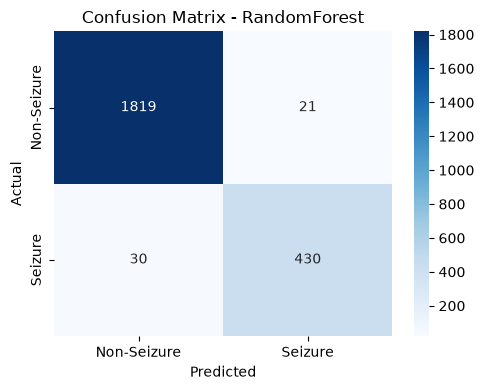

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Seizure", "Seizure"],
            yticklabels=["Non-Seizure", "Seizure"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.show()

<Figure size 500x400 with 0 Axes>

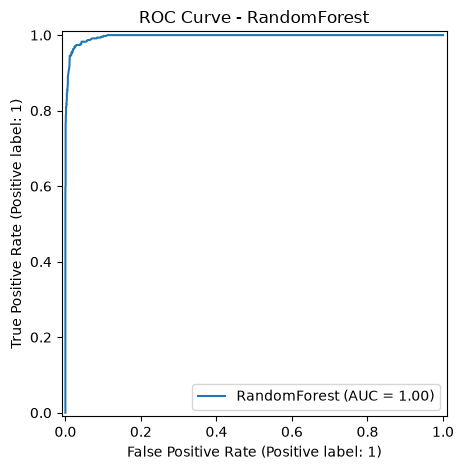

In [11]:
plt.figure(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, best_proba, name=best_name)
plt.title(f"ROC Curve - {best_name}")
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

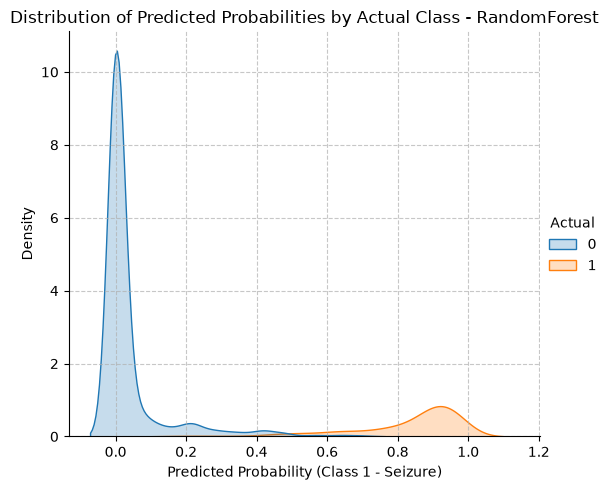

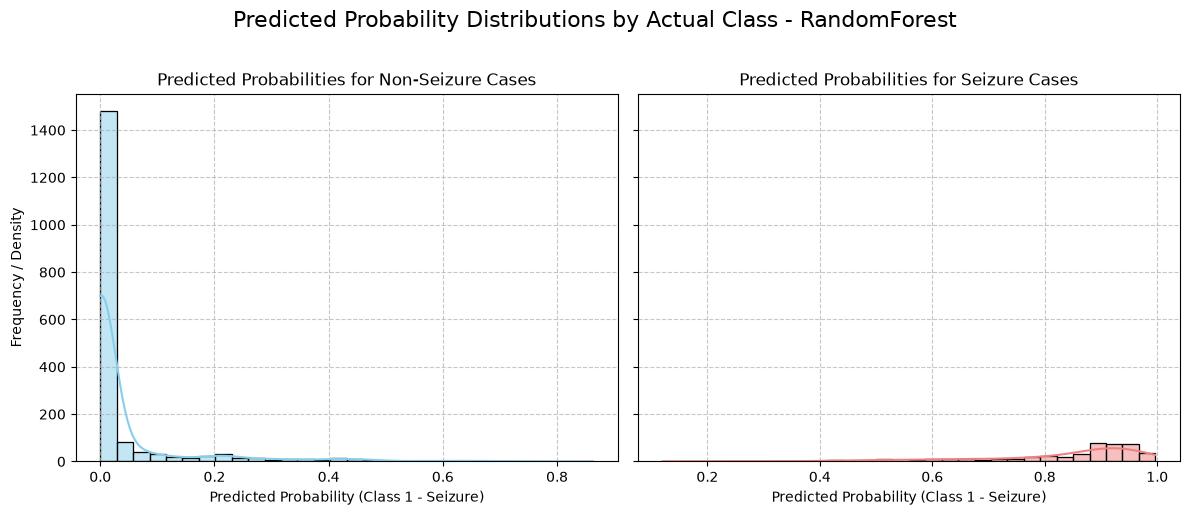

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the predicted probabilities for the best model
best_model_probabilities = fitted[best_name][2]

# Create a DataFrame for plotting, including actual labels and predicted probabilities
plot_df = pd.DataFrame({'Actual': y_test, 'Predicted_Proba': best_model_probabilities})

# Visualize the distribution of predicted probabilities using displot
plt.figure(figsize=(8, 6))
sns.displot(plot_df, x='Predicted_Proba', hue='Actual', kind='kde', fill=True)
plt.title(f'Distribution of Predicted Probabilities by Actual Class - {best_name}')
plt.xlabel('Predicted Probability (Class 1 - Seizure)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Create subplots for the probability distributions of each class
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot for Non-Seizure (Actual = 0)
sns.histplot(plot_df[plot_df['Actual'] == 0]['Predicted_Proba'], kde=True, ax=axes[0], color='skyblue', bins=30)
axes[0].set_title('Predicted Probabilities for Non-Seizure Cases')
axes[0].set_xlabel('Predicted Probability (Class 1 - Seizure)')
axes[0].set_ylabel('Frequency / Density')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot for Seizure (Actual = 1)
sns.histplot(plot_df[plot_df['Actual'] == 1]['Predicted_Proba'], kde=True, ax=axes[1], color='lightcoral', bins=30)
axes[1].set_title('Predicted Probabilities for Seizure Cases')
axes[1].set_xlabel('Predicted Probability (Class 1 - Seizure)')
axes[1].set_ylabel('Frequency / Density')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.suptitle(f'Predicted Probability Distributions by Actual Class - {best_name}', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

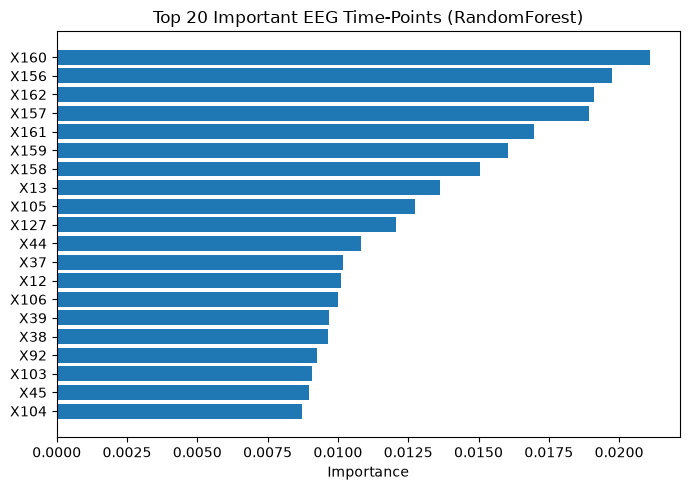

In [13]:
# Feature importance (Only Random Forest is best for it)
if best_name == "RandomForest":
    importances = best_model.feature_importances_
    top_idx = np.argsort(importances)[::-1][:20]
    plt.figure(figsize=(7, 5))
    plt.barh([f"X{i+1}" for i in top_idx][::-1], importances[top_idx][::-1])
    plt.xlabel("Importance")
    plt.title("Top 20 Important EEG Time-Points (RandomForest)")
    plt.tight_layout()
    plt.show()

## Step 6: Save the Best Model

Save the trained model as a `.pkl` file using joblib so it can be reloaded and deployed for future predictions without retraining.

In [14]:
import joblib, os

os.makedirs("outputs", exist_ok=True)
joblib.dump(best_model, "outputs/best_model.pkl")
joblib.dump(scaler, "outputs/scaler.pkl")
print("Model saved to outputs/best_model.pkl")

Model saved to outputs/best_model.pkl


## Conclusion

In this project, we built an end-to-end Machine Learning pipeline to detect epileptic seizures from EEG signals:

- Data Fetching: Scraped metadata using BeautifulSoup and downloaded the dataset with an automated GitHub fallback mechanism.

- Preprocessing: Binarized the target variable, split data with stratification, and scaled features using StandardScaler.

- Model Comparison: Evaluated Logistic Regression, Random Forest, and SVM models.

- Best Model: Random Forest achieved the highest performance across key metrics, particularly F1-score and ROC-AUC.

## Next Steps & Future Improvements

- Explore Deep Learning: Implement 1D-CNN or LSTM models to better capture temporal patterns directly from raw EEG time-series signals.

- Hyperparameter Tuning: Fine-tune model parameters using GridSearchCV or RandomizedSearchCV to optimize accuracy.

- Multi-Class Classification: Expand the project to tackle the original 5-class problem to distinguish between various non-seizure brain activity states.

- Real-Time Deployment: Package the model into an API or web interface to create a real-time seizure monitoring and alert system.

In [16]:
# ============================================================
# REALTIME SEIZURE MONITORING — DEPLOYMENT EXPORT
# Run this CELL inside the Jupyter notebook AFTER model training
# ============================================================

import os
import joblib
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report
)

# ------------------------------------------------------------
# 1. Create output directory
# ------------------------------------------------------------

os.makedirs("outputs", exist_ok=True)


# ------------------------------------------------------------
# 2. Check that the notebook contains the trained variables
# ------------------------------------------------------------

required = [
    "best_model",
    "scaler",
    "best_pred",
    "best_proba",
    "y_test",
    "best_name",
    "results_df"
]

missing = [
    variable
    for variable in required
    if variable not in globals()
]

if missing:

    print("❌ DEPLOYMENT EXPORT CANNOT CONTINUE")
    print()
    print("Missing notebook variables:")
    
    for variable in missing:
        print("   •", variable)

    print()
    print("Make sure you have executed all model-training")
    print("and evaluation cells before running this cell.")

else:

    # --------------------------------------------------------
    # 3. Save trained model
    # --------------------------------------------------------

    joblib.dump(
        best_model,
        "outputs/best_model.pkl"
    )

    # --------------------------------------------------------
    # 4. Save scaler
    # --------------------------------------------------------

    joblib.dump(
        scaler,
        "outputs/scaler.pkl"
    )

    # --------------------------------------------------------
    # 5. Calculate ROC information
    # --------------------------------------------------------

    fpr, tpr, thresholds = roc_curve(
        y_test,
        best_proba
    )

    roc_auc = roc_auc_score(
        y_test,
        best_proba
    )

    # --------------------------------------------------------
    # 6. Create metadata for dashboard
    # --------------------------------------------------------

    metadata = {

        "best_name": best_name,

        "results_df": results_df,

        "confusion_matrix": confusion_matrix(
            y_test,
            best_pred
        ),

        "y_test": np.asarray(
            y_test
        ),

        "best_proba": np.asarray(
            best_proba
        ),

        "fpr": np.asarray(
            fpr
        ),

        "tpr": np.asarray(
            tpr
        ),

        "roc_auc": float(
            roc_auc
        ),

        "classification_report": classification_report(
            y_test,
            best_pred,
            target_names=[
                "Non-Seizure",
                "Seizure"
            ],
            output_dict=True
        )
    }

    # --------------------------------------------------------
    # 7. Save feature importance if supported
    # --------------------------------------------------------

    if hasattr(
        best_model,
        "feature_importances_"
    ):

        metadata[
            "feature_importances"
        ] = np.asarray(
            best_model.feature_importances_
        )

    # --------------------------------------------------------
    # 8. Save metadata
    # --------------------------------------------------------

    joblib.dump(
        metadata,
        "outputs/metadata.joblib"
    )

    # --------------------------------------------------------
    # 9. Final confirmation
    # --------------------------------------------------------

    print("=" * 65)
    print("✅ REALTIME SEIZURE MONITORING EXPORT COMPLETE")
    print("=" * 65)

    print()
    print("Selected model:")
    print("   ", best_name)

    print()
    print("ROC-AUC:")
    print("   ", round(roc_auc, 4))

    print()
    print("Files created:")
    print("   ✓ outputs/best_model.pkl")
    print("   ✓ outputs/scaler.pkl")
    print("   ✓ outputs/metadata.joblib")

    print()
    print("Your Streamlit dashboard can now load these files.")

✅ REALTIME SEIZURE MONITORING EXPORT COMPLETE

Selected model:
    RandomForest

ROC-AUC:
    0.9966

Files created:
   ✓ outputs/best_model.pkl
   ✓ outputs/scaler.pkl
   ✓ outputs/metadata.joblib

Your Streamlit dashboard can now load these files.
